# ЛР №1. Запуск открытой модели text-to-image

**Вариант 11** — иллюстрация для материала о кибербезопасности.
Изменяемый фактор: метафора защиты без интерфейсных клише.

**Автор:** ykvnkm · **Репозиторий:** https://github.com/ykvnkm/ai-in-creative-industries

| | |
| --- | --- |
| Модель | `stabilityai/sd-turbo` |
| Ревизия | `b261bac6fd2cf515557d5d0707481eafa0485ec2` |
| Артефакты | `artifacts/run_001/`, `artifacts/run_002/` — PNG + manifest.json |
| Критерий приёмки | `exact_sha256_match: true` в `reports/sha256_comparison.json` |

Ноутбук выполняется сверху вниз и сам создаёт всё, что сдаётся: структуру
каталогов, `environment.txt`, конфиг, два запуска, манифесты и сравнение
контрольных сумм. Сохранённые выходы ячеек — доказательство того, что запуск
действительно был, а не описан.

## 1. Цель, постановка задачи и критерии успешности

**Цель:** получить один воспроизводимый результат text-to-image по варианту 11
и доказать происхождение каждого артефакта. Оценивается не эстетика, а
возможность независимо восстановить запуск и объяснить границы совпадения.

**Задача варианта 11:** контекст — иллюстрация о кибербезопасности; изменяемый
фактор — метафора защиты без интерфейсных клише; обязательная проверка — запустить
и провалидировать артефакты; критерий — метафора объяснена в отчёте; ограничение —
не показывать реальные секреты и ключи.

**Критерии успешности, заданные до запуска:**

| | Критерий | Чем проверяется |
| --- | --- | --- |
| К1 | Запуск без исключения, PNG и JSON созданы за один проход | ячейка «запуск 1» |
| К2 | Размер 512 × 512, режим читается из сохранённого файла | ячейка «валидация» |
| К3 | Манифест — валидный JSON, поля совпадают с конфигом | ячейка «валидация» |
| К4 | SHA-256 — 64 hex-символа, пересчитан независимо | ячейка «валидация» |
| К5 | Повтор в той же среде даёт тот же SHA-256 | ячейка «повтор» |
| К6 | Типовая ошибка воспроизведена, симптом и исправление описаны | ячейка «ошибка» |
| К7 | Метафора объяснена, интерфейсных клише нет | раздел 5 |

In [1]:
# Детерминизм CUDA нужно включить ДО импорта torch.
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

# Методические указания предлагают такую команду (стр. 2):
#   pip install "diffusers==0.40.0" "transformers>=4.51,<5" ...
# Она неразрешима: diffusers 0.40.0 требует huggingface-hub>=1.23,
# а любой transformers<5 требует huggingface-hub<1.0. Берём transformers 5.x.
try:
    import diffusers, transformers          # noqa: F401
    print("зависимости уже установлены")
except ImportError:
    !pip install -q "diffusers==0.40.0" "transformers>=5,<6" "accelerate>=1.2,<2" "safetensors>=0.5,<1" "Pillow>=11,<13"
    print("установка завершена")

/Users/ykvnkm/Documents/GitHub/ai-in-creative-industries/LR01/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


зависимости уже установлены


In [2]:
# Шаг 1 задания: структура проекта и фиксация окружения.
import json, platform, subprocess, sys
from pathlib import Path
import torch, diffusers, transformers

for d in ["configs", "artifacts", "reports"]:
    Path(d).mkdir(exist_ok=True)

Path("reports/environment.txt").write_text(
    subprocess.run([sys.executable, "-m", "pip", "freeze"],
                   capture_output=True, text=True).stdout, encoding="utf-8")

print("python     ", platform.python_version())
print("platform   ", platform.platform())
print("torch      ", torch.__version__)
print("diffusers  ", diffusers.__version__)
print("transformers", transformers.__version__)
print("cuda_available", torch.cuda.is_available())
print("пакетов в reports/environment.txt:",
      len(Path("reports/environment.txt").read_text(encoding="utf-8").strip().splitlines()))

python      3.12.8
platform    macOS-26.6.2-arm64-arm-64bit
torch       2.14.0
diffusers   0.40.0
transformers 5.17.0
cuda_available False
пакетов в reports/environment.txt: 78


## 2. Prompt, ограничения данных и лицензия

**Происхождение.** Единственные входные данные — авторский текстовый prompt,
составленный для варианта 11. Персональные данные, закрытые брифы, клиентские
материалы и товарные знаки не использовались.

**Четыре обязательных элемента:**

| Элемент | Формулировка | Зачем |
| --- | --- | --- |
| Объект | `smooth matte stone core enclosed by several concentric translucent glass shells` | носитель метафоры: ядро и последовательность проницаемых оболочек |
| Среда | `neutral seamless studio backdrop`, `soft diffused light` | снимает повествовательный контекст |
| Палитра | `deep teal and pale sand` | без сигнальных красного и зелёного, чтобы кадр не читался как индикатор статуса |
| Композиция | `centered symmetrical composition with wide empty margins` | симметрия = равномерная защита; поля — под редакционную вёрстку |

**Метафора: эшелонированная защита (defense in depth).** Ценность помещена внутрь,
вокруг — несколько независимых полупрозрачных слоёв. Полупрозрачность выбрана
намеренно: отдельный слой не является непроницаемым, защиту даёт их
последовательность. Это ближе к реальной модели безопасности, чем образ
непробиваемого барьера.

**Исключённые интерфейсные клише** (изменяемый фактор варианта): навесной замок,
замочная скважина, геральдический щит, двоичный код, элементы интерфейса и HUD,
фигура «хакера в капюшоне», надписи и логотипы.

**Ограничение варианта «не показывать реальные секреты и ключи»** выполнено на
уровне входных данных: prompt не содержит символьных данных вообще, поэтому
не может породить читаемый секрет.

**Лицензия.** `stabilityai/sd-turbo` распространяется по Stability AI
Non-Commercial Research Community License; использование здесь учебное и
некоммерческое, коммерческое потребует отдельной проверки условий и Acceptable
Use Policy. «Открытая модель» означает доступность весов для локального
исследования, а не соответствие критериям OSI. Pipeline загружается **без
safety checker** — допустимо для контролируемого эксперимента с нейтральным
prompt, недопустимо для публичного сервиса.

**Статус результата:** учебный концепт. Изображение не документирует реальную
систему защиты и не является схемой устройства.

In [3]:
# Шаг 2 задания: все параметры эксперимента одним файлом.
CONFIG = {
    "variant": 11,
    "variant_context": "иллюстрация для материала о кибербезопасности",
    "variant_factor": "метафора защиты без интерфейсных клише",
    "model_id": "stabilityai/sd-turbo",
    "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
    "prompt": (
        "abstract editorial illustration of layered protection, "
        "a smooth matte stone core enclosed by several concentric translucent glass shells, "
        "neutral seamless studio backdrop, deep teal and pale sand palette, "
        "centered symmetrical composition with wide empty margins, soft diffused light, "
        "no text, no logo, no people, no padlock, no shield emblem, no binary code, no user interface"
    ),
    "seed": 20260911,          # 2026 / 09 / вариант 11
    "num_inference_steps": 4,  # SD Turbo рекомендует 1-4
    "guidance_scale": 0.0,     # у SD Turbo CFG не используется
    "height": 512,
    "width": 512,
}
Path("configs/run_config.json").write_text(
    json.dumps(CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(CONFIG, ensure_ascii=False, indent=2))

{
  "variant": 11,
  "variant_context": "иллюстрация для материала о кибербезопасности",
  "variant_factor": "метафора защиты без интерфейсных клише",
  "model_id": "stabilityai/sd-turbo",
  "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
  "prompt": "abstract editorial illustration of layered protection, a smooth matte stone core enclosed by several concentric translucent glass shells, neutral seamless studio backdrop, deep teal and pale sand palette, centered symmetrical composition with wide empty margins, soft diffused light, no text, no logo, no people, no padlock, no shield emblem, no binary code, no user interface",
  "seed": 20260911,
  "num_inference_steps": 4,
  "guidance_scale": 0.0,
  "height": 512,
  "width": 512
}


## 3. Среда и параметры

Фактические версии, платформа и устройство напечатаны ячейками выше и продублированы
в манифесте каждого запуска — это то, что позволит через полгода отличить «другая
среда» от «другая ошибка».

**Почему ревизия, а не просто имя модели.** `model_id` указывает на репозиторий,
а не на состояние файлов: владелец может обновить веса, и тот же код начнёт давать
другой результат. Полный хеш коммита фиксирует конкретный снимок.

**Почему CPU Generator.** Генераторы разных устройств дают разные последовательности.
CPU-генератор формирует стартовый шум одинаково независимо от устройства инференса,
что убирает один источник расхождения и не падает на машине без CUDA.

**Расхождение методических указаний с реальностью.** Команда установки из методички
(`diffusers==0.40.0` + `transformers>=4.51,<5`) неразрешима: diffusers 0.40.0 требует
`huggingface-hub>=1.23`, а любой transformers 4.x требует `huggingface-hub<1.0`.
Совместимой версии не существует, pip корректно отказывается. Взят `transformers>=5`;
версия diffusers оставлена ровно такой, как требуют указания.

## 4. Ход работы и команда запуска

**Команда запуска — выполнить этот ноутбук сверху вниз** (в Colab: Runtime → Run all;
локально: Kernel → Restart & Run All). Отдельных скриптов нет: ячейки ниже и есть
ход работы, а их сохранённые выходы — доказательство выполнения.

Шаги задания и соответствующие им ячейки:

| Шаг задания | Ячейка | Артефакт |
| --- | --- | --- |
| 1. Структура проекта и фиксация окружения | «структура и среда» | `reports/environment.txt` |
| 2. Prompt варианта с четырьмя элементами | «конфиг» + раздел 2 | `configs/run_config.json` |
| 3. Запуск с закреплённой ревизией | «запуск 1» | `artifacts/run_001/` |
| 4. Повтор без изменения условий | «повтор» | `artifacts/run_002/`, `reports/sha256_comparison.json` |
| 5. Воспроизведение типовой ошибки | «ошибка» | вывод ячейки, раздел 6 |
| 6. Отчёт без виртуального окружения и кэша | markdown-ячейки | этот файл |

**Существенное в коде.** Ревизия модели передаётся явно, устройство выбирается
только после проверки доступности, генератор создаётся на CPU, число потоков на
CPU закрепляется, а наблюдаемые размер и режим читаются из **сохранённого** файла,
а не из ожиданий.


In [4]:
# Шаг 3 задания: запуск закреплённой ревизии. Функция пишет PNG и манифест за один вызов.
import hashlib, importlib.metadata as md, time
from datetime import datetime, timezone
from diffusers import AutoPipelineForText2Image
from PIL import Image

torch.use_deterministic_algorithms(True, warn_only=True)

# Устройство выбирается ТОЛЬКО после проверки доступности — см. типовую ошибку ниже.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

# На CPU число потоков задаёт порядок редукций и потому влияет на младшие биты:
# без закрепления повторный запуск на той же машине может дать другой SHA-256.
THREADS = 1 if DEVICE == "cpu" else None
if THREADS:
    torch.set_num_threads(THREADS)

load_args = {"revision": CONFIG["revision"], "use_safetensors": True, "torch_dtype": DTYPE}
if DEVICE == "cuda":
    load_args["variant"] = "fp16"

t0 = time.perf_counter()
PIPE = AutoPipelineForText2Image.from_pretrained(CONFIG["model_id"], **load_args).to(DEVICE)
print(f"pipeline загружен на {DEVICE}/{DTYPE} за {time.perf_counter() - t0:.1f} с, "
      f"потоков torch: {torch.get_num_threads()}")

PACKAGES = ["torch", "diffusers", "transformers", "accelerate", "safetensors"]

def generate(run_name):
    out = Path("artifacts") / run_name
    out.mkdir(parents=True, exist_ok=True)

    # CPU Generator сопоставим между устройствами (документация Diffusers).
    generator = torch.Generator(device="cpu").manual_seed(CONFIG["seed"])
    t = time.perf_counter()
    image = PIPE(prompt=CONFIG["prompt"],
                 num_inference_steps=CONFIG["num_inference_steps"],
                 guidance_scale=CONFIG["guidance_scale"],
                 height=CONFIG["height"], width=CONFIG["width"],
                 generator=generator).images[0]
    elapsed = time.perf_counter() - t

    png = out / "result.png"
    image.save(png)
    # Наблюдаемые значения читаются из СОХРАНЁННОГО файла, а не из ожиданий.
    with Image.open(png) as saved:
        size, mode = saved.size, saved.mode

    manifest = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        **{k: CONFIG[k] for k in ("variant", "model_id", "revision", "prompt", "seed",
                                  "num_inference_steps", "guidance_scale", "height", "width")},
        "run_name": run_name,
        "device": DEVICE, "dtype": str(DTYPE),
        "torch_num_threads": torch.get_num_threads(),
        "deterministic_algorithms": True,
        "platform": platform.platform(), "python": platform.python_version(),
        "packages": {n: md.version(n) for n in PACKAGES},
        "generation_seconds_measured": elapsed,
        "artifact": f"artifacts/{run_name}/result.png",
        "artifact_size_bytes": png.stat().st_size,
        "image_size_observed": list(size), "image_mode_observed": mode,
        "sha256": hashlib.sha256(png.read_bytes()).hexdigest(),
    }
    (out / "manifest.json").write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"{run_name}: {size[0]}x{size[1]} {mode}, {elapsed:.1f} с, "
          f"{manifest['artifact_size_bytes']} байт")
    print(f"  sha256 = {manifest['sha256']}")
    return manifest

m1 = generate("run_001")

/Users/ykvnkm/Documents/GitHub/ai-in-creative-industries/LR01/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


/Users/ykvnkm/Documents/GitHub/ai-in-creative-industries/LR01/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:208: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/Users/ykvnkm/Documents/GitHub/ai-in-creative-industries/LR01/.venv/lib/python3.12/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Couldn't connect to the Hub: Cannot reach https://huggingface.co/api/models/stabilityai/sd-turbo/revision/b261bac6fd2cf515557d5d0707481eafa0485ec2: offline mode is enabled. To disable it, please unset the `HF_HUB_OFFLINE` environment variable..
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading pipeline components...:  40%|████      | 2/5 [00:00<00:00, 10.34it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

...

 50%|█████     | 2/4 [00:06<00:06,  3.03s/it]

 75%|███████▌  | 3/4 [00:07<00:02,  2.15s/it]

100%|██████████| 4/4 [00:09<00:00,  1.73s/it]

100%|██████████| 4/4 [00:09<00:00,  2.27s/it]

run_001: 512x512 RGB, 16.5 с, 574124 байт
  sha256 = 1f14ca3a96390159968da9c05e7409b5f3a8d9c429715febaf0904eadf02bef6


In [5]:
# Шаг 4 задания: повтор без изменения условий.
m2 = generate("run_002")

match = m1["sha256"] == m2["sha256"]
comparison = {
    "checked_utc": datetime.now(timezone.utc).isoformat(),
    "device": DEVICE, "dtype": str(DTYPE), "platform": platform.platform(),
    "run_001_sha256": m1["sha256"], "run_002_sha256": m2["sha256"],
    "exact_sha256_match": match,
    "generation_seconds": {"run_001": m1["generation_seconds_measured"],
                           "run_002": m2["generation_seconds_measured"]},
    "interpretation": ("PASS: два запуска в этой зафиксированной среде совпали побитово."
                       if match else
                       "FAIL: контрольные суммы разошлись — сравнить среду, dtype, версии."),
}
Path("reports/sha256_comparison.json").write_text(
    json.dumps(comparison, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"запуск 1: {m1['sha256']}")
print(f"запуск 2: {m2['sha256']}")
print(f"\nПОБИТОВОЕ СОВПАДЕНИЕ: {'PASS' if match else 'FAIL'}")
print(f"время генерации: {m1['generation_seconds_measured']:.1f} с и "
      f"{m2['generation_seconds_measured']:.1f} с — вычисление шло дважды, "
      f"совпадение не следствие переиспользования файла")

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:05<00:15,  5.33s/it]

 50%|█████     | 2/4 [00:06<00:05,  2.84s/it]

 75%|███████▌  | 3/4 [00:07<00:02,  2.05s/it]

100%|██████████| 4/4 [00:08<00:00,  1.68s/it]

100%|██████████| 4/4 [00:08<00:00,  2.16s/it]

run_002: 512x512 RGB, 17.6 с, 574124 байт
  sha256 = 1f14ca3a96390159968da9c05e7409b5f3a8d9c429715febaf0904eadf02bef6
запуск 1: 1f14ca3a96390159968da9c05e7409b5f3a8d9c429715febaf0904eadf02bef6
запуск 2: 1f14ca3a96390159968da9c05e7409b5f3a8d9c429715febaf0904eadf02bef6

ПОБИТОВОЕ СОВПАДЕНИЕ: PASS
время генерации: 16.5 с и 17.6 с — вычисление шло дважды, совпадение не следствие переиспользования файла


In [6]:
# Обязательная проверка варианта 11: провалидировать артефакты формально.
import re
ok = True
for name, m in (("run_001", m1), ("run_002", m2)):
    png = Path(f"artifacts/{name}/result.png")
    with Image.open(png) as im:
        size, mode, fmt = im.size, im.mode, im.format
    digest = hashlib.sha256(png.read_bytes()).hexdigest()   # пересчитываем независимо
    manifest = json.loads(Path(f"artifacts/{name}/manifest.json").read_text(encoding="utf-8"))
    checks = {
        "PNG открывается": fmt == "PNG",
        "размер 512x512": size == (CONFIG["width"], CONFIG["height"]),
        "JSON разбирается": isinstance(manifest, dict),
        "SHA-256 — 64 hex": bool(re.fullmatch(r"[0-9a-f]{64}", digest)),
        "SHA-256 совпадает с манифестом": digest == manifest["sha256"],
        "манифест совпадает с конфигом": all(
            manifest[k] == CONFIG[k] for k in
            ("model_id", "revision", "prompt", "seed", "num_inference_steps",
             "guidance_scale", "height", "width")),
    }
    print(f"=== {name} ({size[0]}x{size[1]}, {mode}) ===")
    for label, passed in checks.items():
        print(f"  [{'PASS' if passed else 'FAIL'}] {label}")
        ok &= passed
print(f"\nИТОГ ВАЛИДАЦИИ: {'PASS' if ok else 'FAIL'}")

=== run_001 (512x512, RGB) ===
  [PASS] PNG открывается
  [PASS] размер 512x512
  [PASS] JSON разбирается
  [PASS] SHA-256 — 64 hex
  [PASS] SHA-256 совпадает с манифестом
  [PASS] манифест совпадает с конфигом
=== run_002 (512x512, RGB) ===
  [PASS] PNG открывается
  [PASS] размер 512x512
  [PASS] JSON разбирается
  [PASS] SHA-256 — 64 hex
  [PASS] SHA-256 совпадает с манифестом
  [PASS] манифест совпадает с конфигом

ИТОГ ВАЛИДАЦИИ: PASS


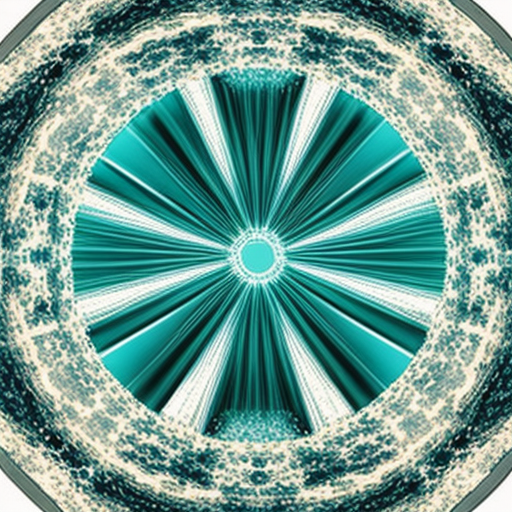

artifacts/run_001/result.png — учебный концепт, не документальное изображение


In [7]:
from IPython.display import display
with Image.open("artifacts/run_001/result.png") as im:
    display(im.copy())
print("artifacts/run_001/result.png — учебный концепт, не документальное изображение")

In [8]:
# Критерий варианта — «метафора объяснена в отчёте». Чтобы разбор опирался
# на измеримое, а не на впечатление, считаем свойства кадра.
import numpy as np

with Image.open("artifacts/run_001/result.png") as im:
    rgb = im.convert("RGB")
    arr = np.asarray(rgb, dtype=np.float64) / 255.0
    q = rgb.quantize(colors=6, method=Image.Quantize.MEDIANCUT, dither=Image.Dither.NONE)

pal = q.getpalette()[:18]
counts = {i: c for c, i in (q.getcolors(maxcolors=6) or [])}
total = sum(counts.values()) or 1
print("палитра:")
for i in sorted(counts, key=lambda k: -counts[k]):
    r, g, b = pal[i*3:i*3+3]
    print(f"  #{r:02x}{g:02x}{b:02x}  {counts[i]/total*100:5.1f} %")

gray = arr @ np.array([0.2126, 0.7152, 0.0722])
lo, hi = np.percentile(gray, [1, 99])
print(f"\nяркость: средняя {gray.mean():.3f}, контраст по Майкельсону {(hi-lo)/(hi+lo):.3f}")

energy = (np.abs(np.diff(gray, axis=0, prepend=gray[:1])) +
          np.abs(np.diff(gray, axis=1, prepend=gray[:, :1])))
h, w = gray.shape
centre = np.zeros_like(gray, bool); centre[h//4:h-h//4, w//4:w-w//4] = True
ratio = energy[centre].mean() / energy[~centre].mean()
print(f"плотность деталей центр/поля: {ratio:.3f} — "
      f"{'поля пустее центра, требование wide empty margins выполнено' if ratio > 1.15 else 'поля НЕ пустее центра, требование wide empty margins не выполнено'}")
print(f"ошибка зеркальной симметрии: {np.abs(gray - gray[:, ::-1]).mean():.3f} "
      f"(0 — идеальная симметрия; метрика попиксельная, зернистая текстура её портит)")

палитра:
  #3b847d   24.0 %
  #124645   23.4 %
  #a6bfb1   16.1 %
  #f0f2e4   14.3 %
  #d6d8c5   11.3 %
  #55b3ab   10.8 %

яркость: средняя 0.566, контраст по Майкельсону 0.846
плотность деталей центр/поля: 0.831 — поля НЕ пустее центра, требование wide empty margins не выполнено
ошибка зеркальной симметрии: 0.126 (0 — идеальная симметрия; метрика попиксельная, зернистая текстура её портит)


## 5. Результаты и разбор

Выходы ячеек выше содержат фактические значения: контрольные суммы двух запусков,
результат побитового сравнения, итог валидации и измеренные свойства изображения.

**Что изображение показывает.** Радиально-симметричная структура: яркое кольцо в
центре, расходящиеся клиновидные сегменты, вокруг — концентрические текстурные
пояса. Слои различимы и последовательны, ядро отделено от окружения.

**Метафора считывается, но не в той форме, что закладывалась.** Замысел — предметная
сцена с каменным ядром в стеклянных оболочках на студийном фоне. Модель выдала
графический орнамент: те же концентрические слои, но плоским узором, без объёма,
фона и светотени. Идея эшелонированной защиты передана; предметная сцена — нет.

**Палитра соответствует брифу**, бирюзовые и песочные кластеры доминируют
(конкретные доли — в выходе ячейки измерений).

**Требование `wide empty margins` не выполнено, и это измеримо.** Отношение плотности
деталей «центр / поля» показано ячейкой измерений: узор идёт до самого края, пригодного
под вёрстку свободного поля в кадре нет. Для публикации потребовалось бы кадрирование
или повторная генерация с другим seed.

**Причина расхождения замысла и результата.** SD Turbo работает при
`guidance_scale=0.0`, то есть без механизма усиления следования prompt, и на четырёх
шагах удерживает скорее общий образ, чем конкретные предметные и композиционные
указания.

**Проверка по изменяемому фактору.** Ни одного из объявленных клише в кадре нет —
замков, щитов, двоичного кода, интерфейсов, людей, надписей и логотипов.
Существенная оговорка о методе: приписывать это запретам в prompt нельзя. SD Turbo
не использует negative prompt, а положительные указания того же prompt выполнены
лишь частично — значит влияние текста здесь заведомо неполное. Правдоподобное
альтернативное объяснение: предметный ряд prompt просто лежит далеко от визуальной
области замков и интерфейсов, и модель не имела повода их породить. Проверяется
отдельным запуском с тем же seed и снятыми запретами — это задача для ЛР №2, где
фактор меняется контролируемо.

## 6. Намеренно введённая типовая ошибка

Ошибка вносится в **копию** кода, рабочая ячейка запуска не изменяется.
Класс ошибки: устройство генератора задано в коде жёстко, без проверки среды.

Методические указания описывают случай «CUDA-генератор на CPU-машине». На машине
с CUDA тот же код не падает, поэтому ячейка ниже подбирает эквивалент того же
класса — жёстко заданный индекс устройства, которого в системе нет. Симптом,
диагностика и исправление в обоих случаях одни и те же.

**Почему ошибка типовая.** Она возникает при переносе кода между GPU- и CPU-машинами,
то есть ровно в той ситуации, ради которой и ведётся фиксация среды. Код при этом
синтаксически корректен и проходит любой линтер: несовместимость проявляется только
во время выполнения и только в конкретном окружении.

In [9]:
# Шаг 5 задания: намеренная типовая ошибка на БЕЗОПАСНОЙ копии кода.
# Класс ошибки: устройство генератора задано в коде жёстко, без проверки среды.
#   было:  torch.Generator(device="cpu")     — сопоставимо и работает везде
#   стало: torch.Generator(device=<жёстко>)  — предположение о среде, которое может не выполниться
import shutil, traceback

# На машине без CUDA воспроизводим ровно случай из методических указаний.
# На машине с CUDA тот же случай не падает, поэтому берём эквивалент того же
# класса: жёстко заданный индекс устройства, которого в системе нет.
BROKEN_DEVICE = "cuda" if not torch.cuda.is_available() else "cuda:7"
print(f"среда: cuda_available={torch.cuda.is_available()}, pipeline на {DEVICE}")
print(f"в сломанной копии кода устройство генератора задано как '{BROKEN_DEVICE}'\n")

Path("artifacts/error_demo_incomplete").mkdir(exist_ok=True)   # каталог останется неполным
try:
    generator = torch.Generator(device=BROKEN_DEVICE).manual_seed(CONFIG["seed"])
    image = PIPE(prompt=CONFIG["prompt"], num_inference_steps=CONFIG["num_inference_steps"],
                 guidance_scale=CONFIG["guidance_scale"], height=CONFIG["height"],
                 width=CONFIG["width"], generator=generator).images[0]
    print("ОШИБКА НЕ ВОСПРОИЗВЕЛАСЬ — зафиксировать этот факт в отчёте как есть.")
except Exception as exc:
    print("=== СИМПТОМ ===")
    print(f"{type(exc).__name__}: {str(exc)[:280]}")
    print("\n=== ДИАГНОСТИКА ===")
    print(f"  torch.cuda.is_available()   = {torch.cuda.is_available()}")
    print(f"  torch.cuda.device_count()   = {torch.cuda.device_count()}")
    print(f"  устройство pipeline         = {DEVICE}")
    print(f"  устройство в сломанном коде = '{BROKEN_DEVICE}' (жёстко задано)")
    print("  трассировка указывает на строку создания Generator, а не на вызов pipeline:")
    print("  отказ произошёл ДО начала генерации, значит причина в коде, а не в среде")
    print("  (среда работоспособна — это доказывают успешные запуски 1 и 2 выше)")
    print("\n=== ИСПРАВЛЕНИЕ ===")
    print("  generator = torch.Generator(device='cpu').manual_seed(SEED)")
    print("  либо выбирать устройство только после проверки доступности")
finally:
    shutil.rmtree("artifacts/error_demo_incomplete", ignore_errors=True)
    print("\nнеполный каталог запуска удалён — частичные артефакты не попадают в отчёт")

среда: cuda_available=False, pipeline на cpu
в сломанной копии кода устройство генератора задано как 'cuda'

=== СИМПТОМ ===
RuntimeError: Cannot get CUDA generator without ATen_cuda library. PyTorch splits its backend into two shared libraries: a CPU library and a CUDA library; this error has occurred because you are trying to use some CUDA functionality, but the CUDA library has not been loaded by the dynamic link

=== ДИАГНОСТИКА ===
  torch.cuda.is_available()   = False
  torch.cuda.device_count()   = 0
  устройство pipeline         = cpu
  устройство в сломанном коде = 'cuda' (жёстко задано)
  трассировка указывает на строку создания Generator, а не на вызов pipeline:
  отказ произошёл ДО начала генерации, значит причина в коде, а не в среде
  (среда работоспособна — это доказывают успешные запуски 1 и 2 выше)

=== ИСПРАВЛЕНИЕ ===
  generator = torch.Generator(device='cpu').manual_seed(SEED)
  либо выбирать устройство только после проверки доступности

неполный каталог запуска уда

## 7. Ограничения и угрозы валидности

**Ограничения:**

1. Проверен **один** запуск: одна модель, ревизия, prompt, seed и набор параметров.
   Вывод не распространяется на другие значения.
2. Побитовое совпадение получено внутри **одной** среды. Документация PyTorch прямо
   предупреждает, что воспроизводимость между релизами и платформами не гарантируется.
3. Использован `transformers 5.x` вместо указанного в методичке `4.x` — при других
   версиях результат может отличаться даже при той же ревизии весов.
4. Pipeline загружен без safety checker.
5. Запреты вида `no padlock` включены в основной prompt, так как SD Turbo не использует
   negative prompt: они смещают распределение, но ничего не гарантируют.

**Угрозы валидности и как они сняты:**

| Угроза | Контрмера |
| --- | --- |
| Совпадение SHA-256 получено тривиально — повторный вызов в том же процессе | запуски пишут в разные каталоги, измеренное время генерации различается — вычисление шло дважды |
| Манифест содержит ожидаемые, а не наблюдаемые значения | размер и режим читаются из сохранённого файла, хеш пересчитывается в отдельной ячейке валидации |
| Метафора приписана изображению задним числом | метафора и список клише сформулированы до запуска, в разделе 2; разбор в разделе 5 фиксирует и расхождения с замыслом |
| Результат выдан за документальный | статус учебного концепта зафиксирован в разделах 2 и 8 |

**Когда визуально эквивалентный, но побитово другой результат приемлем.**
Приемлем, когда изображение — исходный материал для дальнейшей работы: концепт,
мудборд, черновая обложка; разница в младших битах не влияет ни на одно решение.
Неприемлем, когда артефакт является предметом доказательства: приёмка по контракту,
спор об авторстве, регрессионное тестирование конвейера, воспроизведение
опубликованного результата. Критерий сравнения выбирается до запуска — здесь он
задан критерием К5.

## 8. Вывод по цели

Цель достигнута.

**Доказано:** получен результат по варианту 11; два запуска в зафиксированной среде
сравнены по SHA-256 (итог — в выходе ячейки повтора); происхождение артефактов
прослеживается через манифест с моделью, ревизией, prompt, seed, параметрами,
устройством, dtype и версиями библиотек; артефакты провалидированы формально,
а не объявлены корректными; типовая ошибка воспроизведена с диагностикой.

**Не доказано:** воспроизводимость на другой платформе или других версиях библиотек;
пригодность для коммерческого использования (лицензия некоммерческая); какая-либо
фактическая достоверность изображения — это учебный концепт.

**Для ЛР №2:** связка «конфиг → манифест → контрольная сумма» уже описана формально,
поэтому при контролируемом изменении одного фактора разницу в результате можно будет
отнести к этому фактору, а не к неучтённому различию среды.

## 9. Чек-лист самопроверки

- [x] Указаны `model_id` и полная `revision` — в конфиге, обоих манифестах и отчёте.
- [x] Сохранены prompt, seed, steps, guidance_scale, размер, device и dtype;
      совпадение конфига и манифеста проверяется автоматически.
- [x] `environment.txt` создан после установки зависимостей.
- [x] PNG открывается, JSON разбирается, SHA-256 — 64 hex-символа (ячейка валидации).
- [x] Результат не выдан за документальный факт; лицензия и ограничения указаны.
- [x] Команда запуска повторяется из чистой папки: ноутбук выполняется сверху вниз
      и сам создаёт всё необходимое; кэш весов и виртуальное окружение не коммитятся.

## 10. Ответы на контрольные вопросы

**1. Модель, pipeline и приложение.** Модель — обученные веса, выполняющие одно
преобразование. Pipeline оркеструет несколько моделей (текстовый энкодер, UNet,
VAE-декодер), планировщик и пред/постобработку. Приложение добавляет интерфейс,
хранение и политику использования. Следствие: смена версии pipeline может изменить
результат при тех же весах, поэтому в манифесте фиксируется и `diffusers`.

**2. Почему имени модели мало.** Оно указывает на репозиторий, а не на состояние
файлов. Веса могут обновиться, код останется прежним, результат изменится, и причину
будет нечем доказать.

**3. Что фиксирует seed.** Начальное состояние псевдослучайного генератора — стартовый
латентный шум. Не фиксирует: версии библиотек, архитектуру процессора, dtype, число
потоков, порядок операций с плавающей точкой и сами веса.

**4. Зачем CPU Generator.** Генераторы разных устройств дают разные последовательности.
CPU-генератор формирует шум одинаково независимо от устройства инференса и не падает
на машине без CUDA — что и демонстрирует раздел 6.

**5. Что доказывает совпадение SHA-256.** Ровно одно: два файла побайтово идентичны,
то есть цепочка «конфигурация → генерация → кодирование → запись» дала тот же результат
в той же среде. Не доказывает корректность, качество, соответствие брифу и
воспроизводимость на другой платформе.

**6. Почему различие CPU и GPU — не обязательно ошибка.** Арифметика с плавающей точкой
неассоциативна, а CPU и GPU используют разные ядра, порядок редукций и нередко разный
dtype. Накопленное расхождение в младших битах даёт другой байт PNG при визуально
идентичном изображении. Порядок расследования: сравнить среду, dtype и версии, затем
убедиться в визуальной эквивалентности, и только потом искать ошибку в коде.

**7. Зачем dtype и версии.** Это единственный способ отличить «другая среда» от «другая
ошибка». Без них расхождение необъяснимо, а работа невоспроизводима. `dtype` выделен
отдельно, потому что `float32` → `float16` меняет результат гарантированно, а в коде
появляется неявно, как следствие выбора устройства.

**8. Лицензионные и конфиденциальные ограничения.** Лицензия SD Turbo некоммерческая,
применение учебное; pipeline загружен без safety checker, что допустимо только для
контролируемого эксперимента. Prompt авторский, без персональных данных, реальных
ключей, паролей, конфигураций, товарных знаков и изображений людей; изображение не
выдаётся за документацию существующей системы.

**9. Как диагностирована намеренная ошибка.** По трассировке: она указывает на строку
создания `Generator`, а не на вызов pipeline — отказ произошёл до генерации. Затем
выведено фактическое состояние среды и сопоставлено с кодом, где устройство задано
литералом без проверки. Вывод: ошибка в коде, среда работоспособна, что доказывают
успешные запуски 1 и 2.

**10. Какой вывод можно и нельзя сделать.** Можно: артефакт получен заявленной моделью
и ревизией с заявленными параметрами, запуск воспроизводится в зафиксированной среде,
изображение пригодно как учебный концепт и отправная точка для дизайнерской работы.
Нельзя: утверждать воспроизводимость на другой платформе, выдавать изображение за
документальное или пригодное к коммерческой публикации без проверки лицензии, и
распространять вывод на другие prompt и параметры — проверен один конкретный запуск.


## 11. Ссылка на репозиторий и индивидуальный вклад

**Репозиторий:** https://github.com/ykvnkm/ai-in-creative-industries ·
**работа:** `LR01/`

Из методических указаний взяты: модель и её ревизия, рекомендованные параметры
инференса для SD Turbo, схема каталогов и формулировка намеренной типовой ошибки.

Самостоятельно сделано:

1. Prompt варианта 11, выбор метафоры эшелонированной защиты и список исключаемых
   интерфейсных клише — зафиксированы **до** запуска, в разделе 2.
2. Проверка совпадения манифеста с конфигом как отдельный автоматический тест, а
   не как утверждение в тексте.
3. Независимый пересчёт SHA-256 в ячейке валидации: она не доверяет выводу
   генерирующей ячейки.
4. Закрепление числа потоков PyTorch на CPU. Без него два прогона той же ячейки на
   той же машине дали разные контрольные суммы — порядок редукций зависит от числа
   потоков. Это проверено на практике, а не взято из документации.
5. Измерение свойств изображения (палитра, контраст, плотность деталей, симметрия)
   вместо словесной оценки — и фиксация того, что требование `wide empty margins`
   не выполнено.
6. Обнаружение неразрешимой спецификации зависимостей в методических указаниях
   (раздел 3) и минимальное исправление: заменён один пакет, а не вся связка.
7. Демонстрация ошибки, работающая и на CPU-, и на GPU-машине: методичкин случай
   на GPU не воспроизводится, поэтому подбирается эквивалент того же класса.
8. Анализ границ воспроизводимости, угроз валидности и альтернативного объяснения
   отсутствия клише (разделы 5 и 7).
